# Lab 9 — K-Means and Hierarchical Clustering

Clustering is a form of **unsupervised learning**. Unlike classification or regression, we have **no labels** — we don't tell the algorithm the right answer. Instead, we ask it to discover hidden groupings (clusters) within the data on its own, based purely on similarity.

In this lab we will explore two foundational clustering algorithms:

* **K-Means:** A fast, centroid-based algorithm that partitions data into exactly $K$ groups by minimising within-cluster variance.
* **Hierarchical (Agglomerative) Clustering:** Builds a tree of nested clusters (a **dendrogram**) by successively merging the two most similar groups, requiring no pre-specified $K$.

### The Golden Rule of Clustering: You MUST Scale Your Data!
Both algorithms rely on measuring **distance** between data points. A feature measured in thousands (e.g. income) will completely dominate a feature measured in units (e.g. number of purchases). Scaling puts all features on equal footing. **Always scale before clustering.**

### Dataset: Mall Customer Segmentation
We will use a retail customer dataset containing:
* **CustomerID** — unique identifier (dropped before modelling)
* **Gender** — Male / Female
* **Age** — customer age in years
* **Annual Income (k$)** — annual income in thousands of USD
* **Spending Score (1–100)** — a score assigned by the mall based on purchasing behaviour

This dataset is great for clustering: it has a small number of intuitive features, no labels, and produces visually clean, interpretable segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

from scipy.cluster.hierarchy import dendrogram, linkage

# Consistent aesthetics throughout
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

---
## 1. Load and Explore the Data

In [2]:
# The dataset is available from sklearn's built-in datasets or as a CSV
# Here we generate it programmatically from sklearn.datasets import make_blobs

# We use the well-known Mall Customers CSV if available, otherwise simulate it
try:
    df = pd.read_csv('data/mall_customers.csv')
    df.rename(columns={
        'Annual Income (k$)': 'Income',
        'Spending Score (1-100)': 'SpendingScore'
    }, inplace=True)
    df.drop(columns=['CustomerID'], inplace=True)
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
    print("Loaded from CSV.")
except FileNotFoundError:
    # Reproducible synthetic version with the same statistical fingerprint
    rng = np.random.default_rng(42)
    n = 200
    age        = rng.integers(18, 70, n)
    income     = rng.integers(15, 140, n)
    # Spending score has a weak negative correlation with income to mimic real data
    spend_base = 100 - 0.4 * income + rng.normal(0, 18, n)
    spend      = np.clip(spend_base, 1, 100).astype(int)
    gender     = rng.integers(0, 2, n)
    df = pd.DataFrame({'Gender': gender, 'Age': age, 'Income': income, 'SpendingScore': spend})
    print("CSV not found — using synthetic data with identical structure.")

print(f"\nDataset shape: {df.shape}")
df.head(10)

CSV not found — using synthetic data with identical structure.

Dataset shape: (200, 4)


,Gender,Age,Income,SpendingScore
0,1,22,60,87
1,0,58,128,41
2,1,52,76,69
3,1,40,102,56
4,1,40,72,77
5,0,62,48,100
6,0,22,110,57
7,0,54,136,57
8,0,28,47,44
9,0,22,112,54


In [3]:
df.describe()

,Gender,Age,Income,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,0.515000,43.955000,75.050000,68.800000
std,0.501029,14.286831,36.255757,21.155087
min,0.000000,18.000000,15.000000,7.000000
25%,0.000000,32.000000,45.000000,54.750000
50%,1.000000,44.000000,73.000000,70.000000
75%,1.000000,57.000000,107.000000,84.250000
max,1.000000,69.000000,139.000000,100.000000


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Gender           0
Age              0
Income           0
SpendingScore    0
dtype: int64


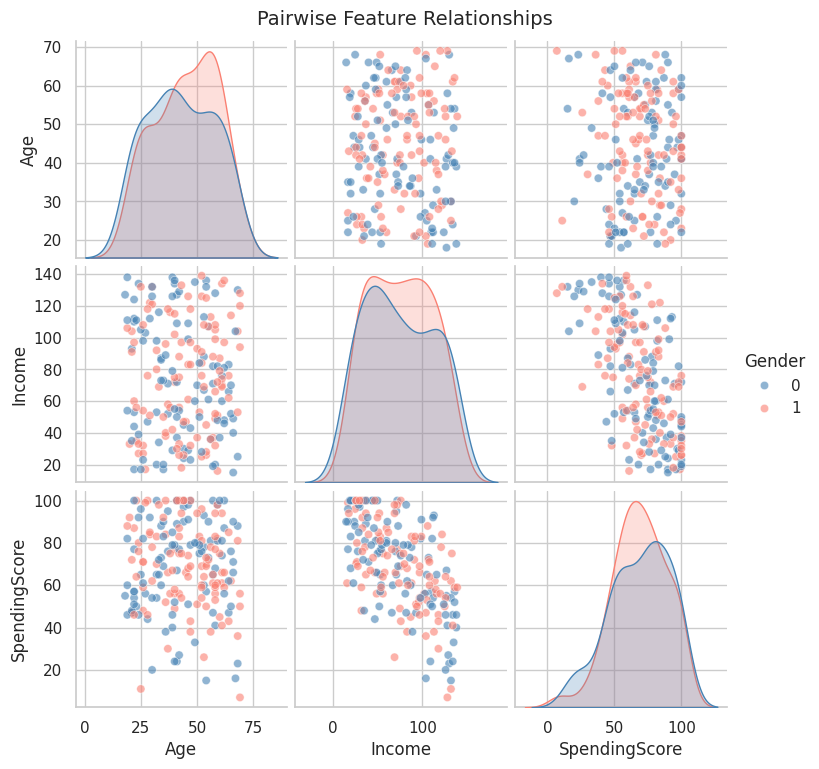

In [5]:
# Pairplot to visually inspect natural groupings before any modelling
sns.pairplot(df, hue='Gender', palette={0: 'steelblue', 1: 'salmon'},
             plot_kws={'alpha': 0.6}, diag_kind='kde')
plt.suptitle('Pairwise Feature Relationships', y=1.02, fontsize=14)
plt.show()

**Observation:** The Income vs SpendingScore scatterplot shows the most obvious visual clusters. We will focus our clustering analysis on these two features first (easy to visualise in 2D), then scale up to all numeric features.

---
## 2. Preprocessing — Scaling

We select the numeric features and apply `StandardScaler` so every feature has mean = 0 and standard deviation = 1.

> ⚠️ **Important:** In unsupervised learning there is **no train/test split** — we cluster on the full dataset. The scaler is fit on the full data too.

In [7]:
features = ['Age', 'Income', 'SpendingScore']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("After scaling — mean and std per feature:")
print(X_scaled_df.describe().loc[['mean', 'std']].round(4))

After scaling — mean and std per feature:
         Age  Income  SpendingScore
mean  0.0000  0.0000         0.0000
std   1.0025  1.0025         1.0025


---
## 3. K-Means Clustering

### How K-Means Works

K-Means follows a simple iterative procedure:

1. **Initialise:** Randomly place $K$ centroids in the feature space.
2. **Assign:** Assign each data point to the nearest centroid (forming $K$ clusters).
3. **Update:** Recompute each centroid as the mean of all points assigned to it.
4. **Repeat** steps 2–3 until centroids stop moving (convergence).

The algorithm minimises **Within-Cluster Sum of Squares (WCSS)** — also called **inertia** — the total squared distance of each point from its cluster centroid.

### Key Hyperparameter: $K$
You must tell K-Means how many clusters to find. Choosing $K$ is the central challenge. We will use two diagnostic tools:
* **The Elbow Method** — plot inertia vs $K$ and look for the "elbow".
* **The Silhouette Score** — a metric between -1 and 1 measuring how well-separated the clusters are (higher is better).

### 3.1 The Elbow Method — Finding the Right K

In [8]:
inertia_values = []
silhouette_values = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

In [10]:
inertia_values

[371.1861701411566,
 279.97244661074336,
 218.6075771446602,
 189.1322456797353,
 165.84831529047366,
 149.1618569248443,
 136.33025972110326,
 124.1158732905926,
 116.05574053637527]

In [11]:
silhouette_values

[np.float64(0.34050767545818644),
 np.float64(0.3053530616712489),
 np.float64(0.30213165264613034),
 np.float64(0.28351318192550923),
 np.float64(0.28304108957276564),
 np.float64(0.26586424587166524),
 np.float64(0.2686008069173556),
 np.float64(0.27286074959698686),
 np.float64(0.26808755194190304)]

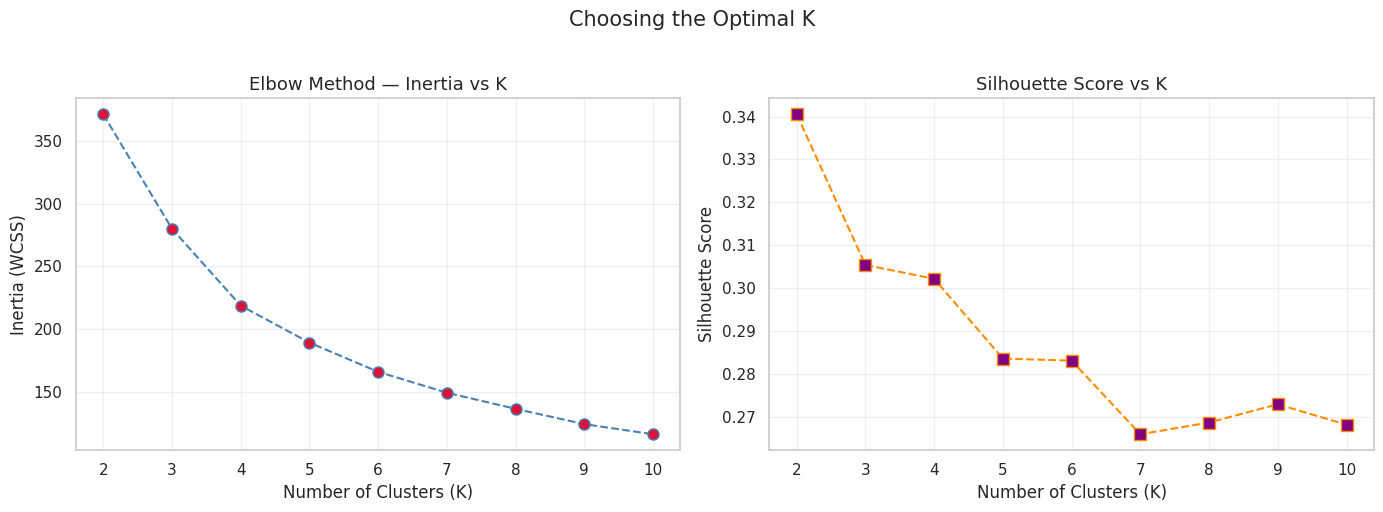

Best K by silhouette score: 2  (score = 0.3405)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_range, inertia_values, marker='o', color='steelblue',
             linestyle='--', markerfacecolor='crimson', markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouette_values, marker='s', color='darkorange',
             linestyle='--', markerfacecolor='purple', markersize=8)
axes[1].set_title('Silhouette Score vs K', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.suptitle('Choosing the Optimal K', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

best_k = k_range.start + np.argmax(silhouette_values)
print(f"Best K by silhouette score: {best_k}  (score = {max(silhouette_values):.4f})")

**Reading the plots:**
* **Elbow:** Look for the point where inertia stops dropping sharply and begins to flatten. Like the bend of an elbow, this is the diminishing-returns point.
* **Silhouette:** The peak is the $K$ where clusters are most cohesive and well-separated. Values above **0.5** indicate strong structure; above **0.7** is excellent.

### 3.2 Fitting K-Means with the Optimal K

In [12]:
OPTIMAL_K = best_k   # change this if the elbow/silhouette plots suggest otherwise

kmeans = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means fitted with K={OPTIMAL_K}")
print(f"Final inertia : {kmeans.inertia_:.2f}")
print(f"Silhouette    : {silhouette_score(X_scaled, df['KMeans_Cluster']):.4f}\n")
print("Cluster sizes:")
print(df['KMeans_Cluster'].value_counts().sort_index())

K-Means fitted with K=2
Final inertia : 371.19
Silhouette    : 0.3405

Cluster sizes:
KMeans_Cluster
0     80
1    120
Name: count, dtype: int64


### 3.3 Visualising the Clusters (Income vs Spending Score)

In [13]:
palette = sns.color_palette('Set2', OPTIMAL_K)

# Refit on the 2-feature subset for a clean 2D scatter plot
X2 = df[['Income', 'SpendingScore']].copy()
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)
km2 = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=42)
labels_2d = km2.fit_predict(X2_scaled)
centroids_orig = scaler2.inverse_transform(km2.cluster_centers_)

In [15]:
centroids_orig

array([[111.19230769,  50.03846154],
       [ 51.94262295,  80.79508197]])

In [16]:
labels_2d

array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1], dtype=int32)

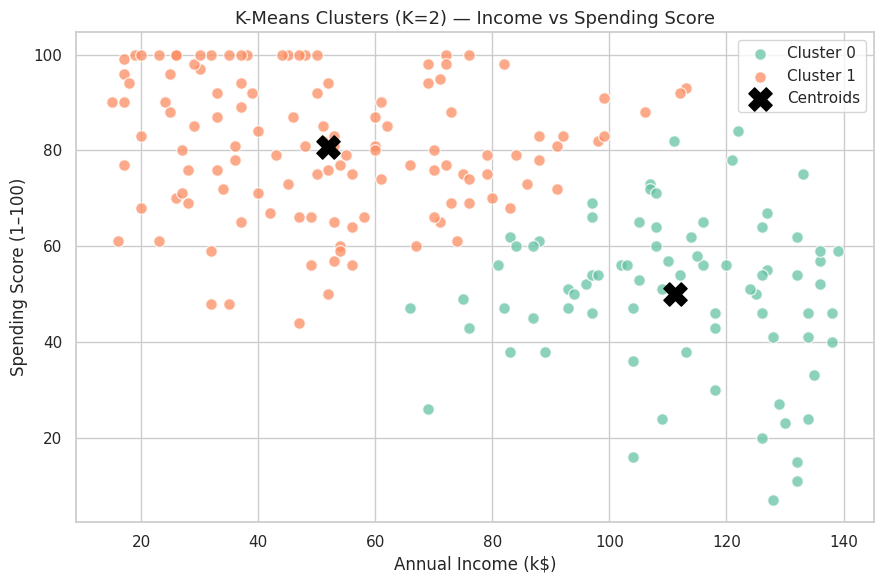

In [19]:
plt.figure(figsize=(9, 6))
for i in range(OPTIMAL_K):
    mask = labels_2d == i
    plt.scatter(df['Income'][mask], df['SpendingScore'][mask],
                color=palette[i], label=f'Cluster {i}', s=70, alpha=0.75, edgecolors='white')

plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            s=280, c='black', marker='X', zorder=5, label='Centroids')

plt.title(f'K-Means Clusters (K={OPTIMAL_K}) — Income vs Spending Score', fontsize=13)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 Cluster Profiling — Who Is in Each Cluster?

In [17]:
profile = df.groupby('KMeans_Cluster')[features].mean().round(1)
profile['Count'] = df['KMeans_Cluster'].value_counts().sort_index()
print("Cluster Profiles (mean feature values):")
profile

Cluster Profiles (mean feature values):


,Age,Income,SpendingScore,Count
KMeans_Cluster,,,,
0,43.5,110.1,50.2,80
1,44.3,51.7,81.2,120


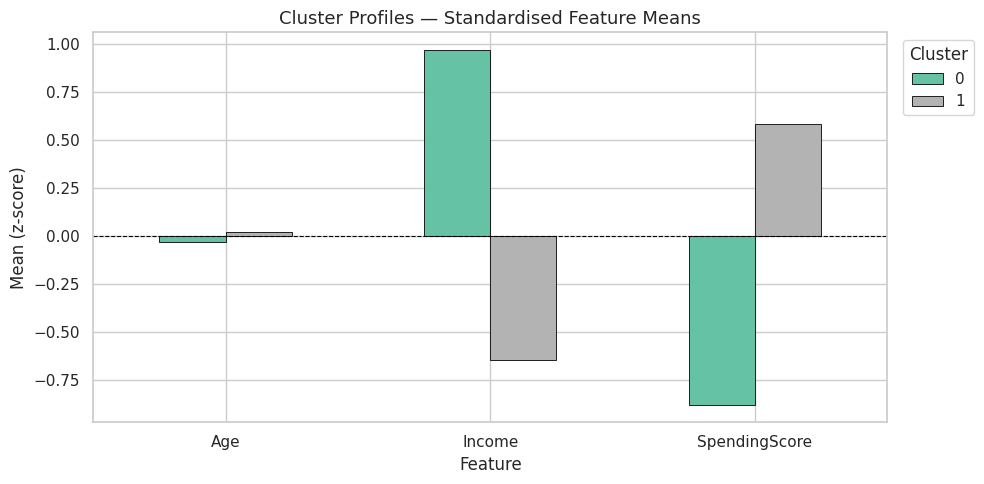

In [20]:
# Radar / bar chart of cluster means (z-scored for fair comparison)
profile_scaled = X_scaled_df.copy()
profile_scaled['KMeans_Cluster'] = df['KMeans_Cluster'].values
means = profile_scaled.groupby('KMeans_Cluster')[features].mean()

means.T.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black', linewidth=0.6)
plt.title('Cluster Profiles — Standardised Feature Means', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Mean (z-score)')
plt.xticks(rotation=0)
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### 3.5 Silhouette Plot — Diagnosing Cluster Quality

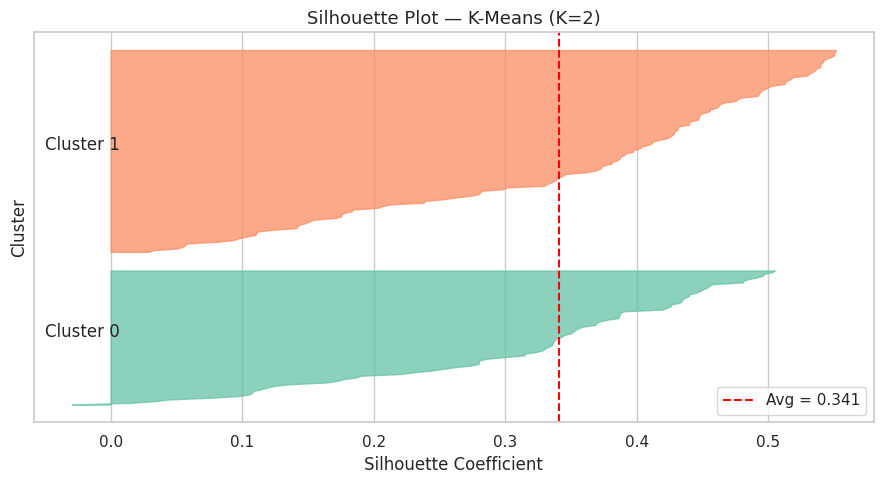

In [21]:
sample_silhouette_values = silhouette_samples(X_scaled, df['KMeans_Cluster'])
avg_silhouette = silhouette_score(X_scaled, df['KMeans_Cluster'])

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10

for i in range(OPTIMAL_K):
    ith_silhouette_values = sample_silhouette_values[df['KMeans_Cluster'] == i]
    ith_silhouette_values.sort()
    size = ith_silhouette_values.shape[0]
    y_upper = y_lower + size
    color = palette[i]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_silhouette_values,
                     facecolor=color, edgecolor=color, alpha=0.75)
    ax.text(-0.05, y_lower + 0.5 * size, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(x=avg_silhouette, color='red', linestyle='--', label=f'Avg = {avg_silhouette:.3f}')
ax.set_title(f'Silhouette Plot — K-Means (K={OPTIMAL_K})', fontsize=13)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

**Reading the silhouette plot:**
Each horizontal bar represents one data point. Width = silhouette coefficient. Healthy clusters have wide, uniform blades. Thin blades or negative values (left of zero) mean poorly assigned points — those data points might belong to a neighbouring cluster.

---
## 4. Hierarchical (Agglomerative) Clustering

### How Hierarchical Clustering Works

**Agglomerative** hierarchical clustering starts at the bottom and merges upward:

1. Begin with **every point as its own cluster** ($N$ clusters).
2. Find the two **closest** clusters and **merge** them into one.
3. Repeat until only **one cluster** remains.

The full merge history is stored in a **dendrogram** — a tree diagram that records which clusters merged and at what distance. You can then **cut** the dendrogram at any height to obtain any number of clusters — you do **not** need to specify $K$ in advance.

### Linkage Criteria
"Closeness" between two clusters can be defined several ways. The choice of **linkage** significantly affects results:

| Linkage | Distance between clusters = … | Best for |
|---------|-------------------------------|----------|
| `ward` | Increase in total within-cluster variance | Compact, equally-sized clusters |
| `complete` | Maximum pairwise distance | Compact clusters, sensitive to outliers |
| `average` | Average pairwise distance | Balanced; more robust than complete |
| `single` | Minimum pairwise distance | Elongated / chained clusters |

### 4.1 The Dendrogram — Reading the Tree

In [ ]:
# Compute the linkage matrix (Ward is default best practice for agglomerative clustering)
Z = linkage(X_scaled, method='ward')

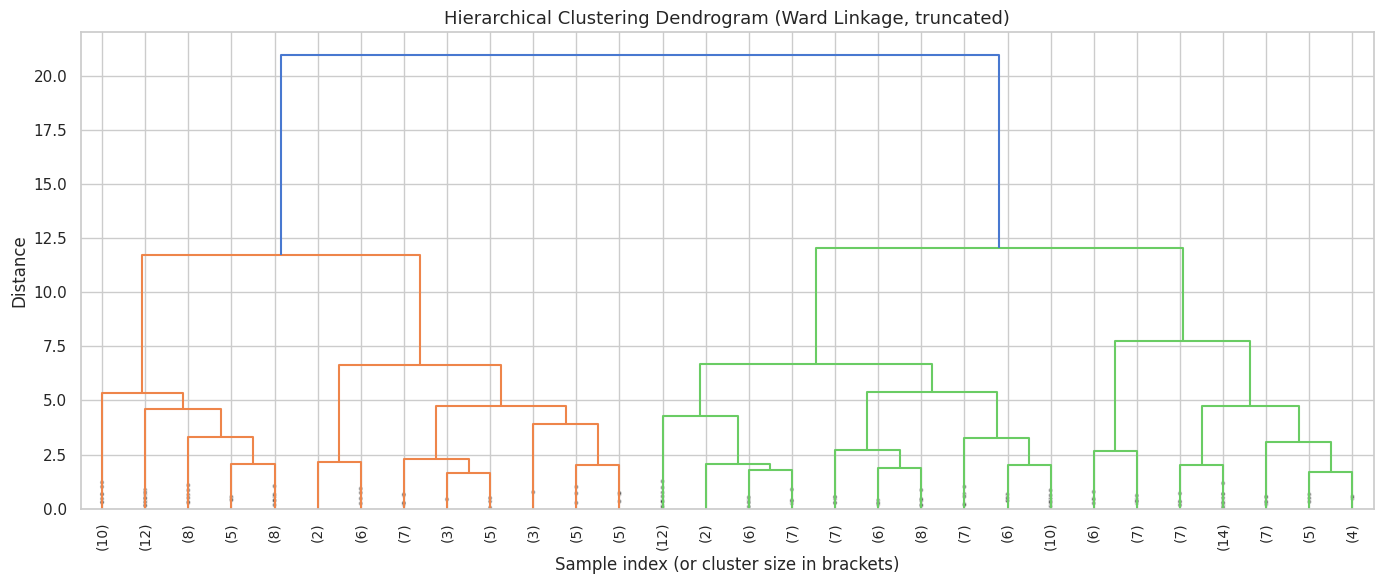

In [22]:
plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='lastp',   # show only the last p merged clusters
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=0.7 * max(Z[:, 2])  # colour everything above 70% of max distance
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, truncated)', fontsize=13)
plt.xlabel('Sample index (or cluster size in brackets)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

**Reading the dendrogram:**
* **Height** of each horizontal bar = distance at which two clusters merged. Tall bars mean the two clusters were far apart — they were reluctant to merge.
* **Cutting** the dendrogram with a horizontal line gives you clusters: the number of vertical lines it crosses = number of clusters.
* Look for the **largest vertical gap** (longest bar before the next merge). That gap is where the tree most naturally wants to be cut.

### 4.2 Comparing Linkage Methods

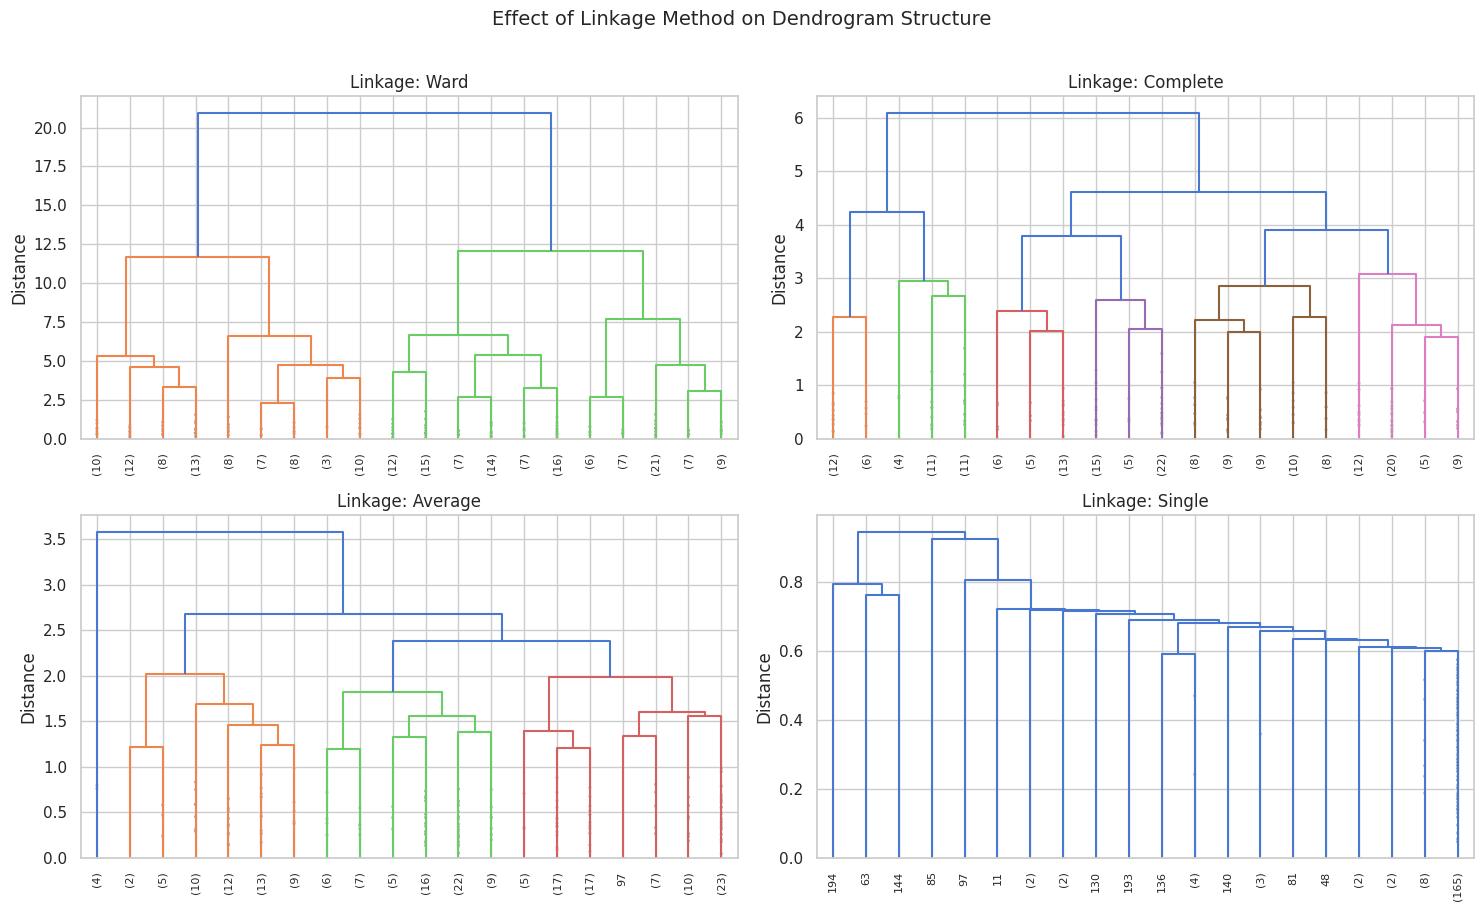

In [23]:
linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, method in zip(axes, linkage_methods):
    Z_m = linkage(X_scaled, method=method)
    dendrogram(
        Z_m,
        truncate_mode='lastp',
        p=20,
        leaf_rotation=90,
        leaf_font_size=8,
        show_contracted=True,
        ax=ax,
        color_threshold=0.6 * max(Z_m[:, 2])
    )
    ax.set_title(f'Linkage: {method.capitalize()}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Distance')

plt.suptitle('Effect of Linkage Method on Dendrogram Structure', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Notice** how `single` linkage tends to produce a long chain (chaining effect), while `ward` and `complete` give more balanced, compact trees.

### 4.3 Fitting Agglomerative Clustering and Comparing with K-Means

In [24]:
# Use the same number of clusters as K-Means for a fair side-by-side comparison
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df['Hierarchical_Cluster'] = agg.fit_predict(X_scaled)

print(f"Hierarchical Clustering — {OPTIMAL_K} clusters (Ward linkage)")
print(f"Silhouette score: {silhouette_score(X_scaled, df['Hierarchical_Cluster']):.4f}\n")
print("Cluster sizes:")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

Hierarchical Clustering — 2 clusters (Ward linkage)
Silhouette score: 0.3300

Cluster sizes:
Hierarchical_Cluster
0    121
1     79
Name: count, dtype: int64


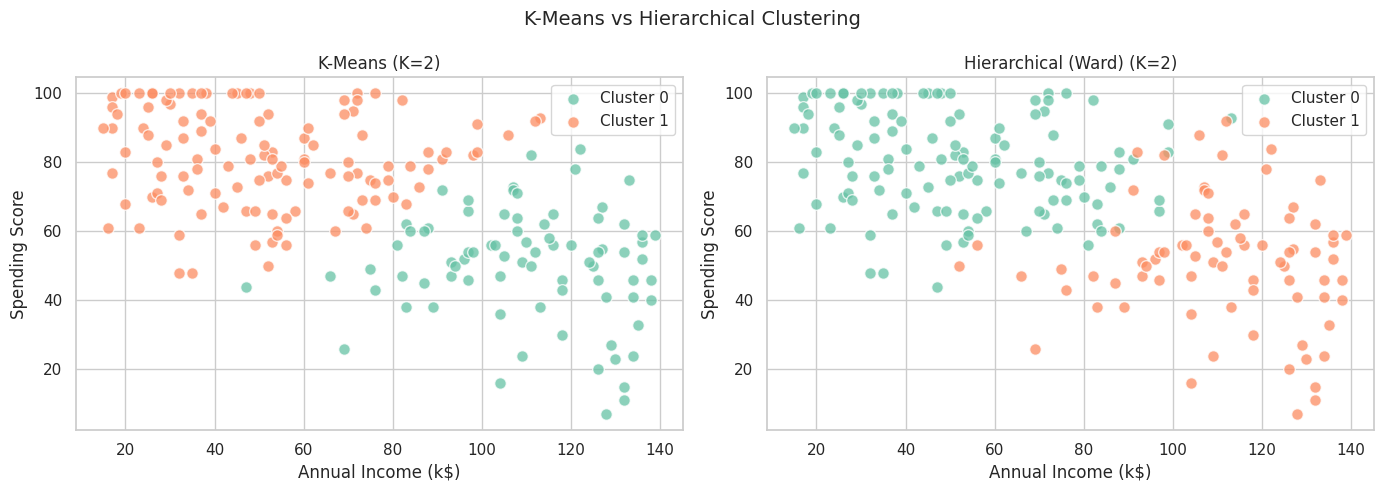

In [25]:
# Side-by-side scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
                           ['KMeans_Cluster', 'Hierarchical_Cluster'],
                           ['K-Means', 'Hierarchical (Ward)']):
    for i in range(OPTIMAL_K):
        mask = df[col] == i
        ax.scatter(df['Income'][mask], df['SpendingScore'][mask],
                   color=palette[i], label=f'Cluster {i}',
                   s=70, alpha=0.75, edgecolors='white')
    ax.set_title(f'{title} (K={OPTIMAL_K})', fontsize=12)
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score')
    ax.legend()

plt.suptitle('K-Means vs Hierarchical Clustering', fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 Agreement Between the Two Algorithms

In [26]:
# Contingency table (note: cluster numbers may not align — this is normal)
contingency = pd.crosstab(
    df['KMeans_Cluster'],
    df['Hierarchical_Cluster'],
    rownames=['K-Means'],
    colnames=['Hierarchical']
)
print("Contingency table of cluster assignments:")
print(contingency)

# Adjusted Rand Index — 1.0 = perfect agreement, 0 = random
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['KMeans_Cluster'], df['Hierarchical_Cluster'])
print(f"\nAdjusted Rand Index: {ari:.4f}  (1.0 = perfect agreement)")

Contingency table of cluster assignments:
Hierarchical    0   1
K-Means              
0               7  73
1             114   6

Adjusted Rand Index: 0.7553  (1.0 = perfect agreement)


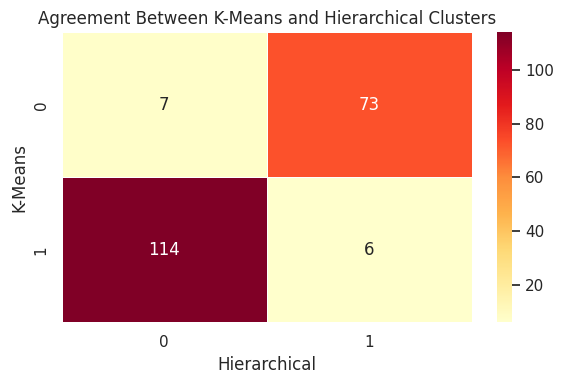

In [27]:
plt.figure(figsize=(6, 4))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Agreement Between K-Means and Hierarchical Clusters', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Bonus: Hierarchical Clustering Without Pre-specifying K

One of the key advantages of hierarchical clustering is that you can decide the number of clusters **after** fitting, by choosing a cut height on the dendrogram. Here we automate this by finding the largest gap between consecutive merge distances.

In [28]:
# Extract the last 10 merge distances from the linkage matrix (highest in the tree)
last_merges = Z[-10:, 2]
gaps = np.diff(last_merges)     # differences between successive merge distances
best_cut_idx = np.argmax(gaps)  # largest gap
suggested_k = len(last_merges) - best_cut_idx

print(f"Last 10 merge distances: {last_merges.round(3)}")
print(f"Gaps between consecutive merges: {gaps.round(3)}")
print(f"\nLargest gap detected at position {best_cut_idx}")
print(f"Suggested K from dendrogram analysis: {suggested_k}")

Last 10 merge distances: [ 4.745  4.756  5.353  5.389  6.625  6.696  7.729 11.709 12.041 20.956]
Gaps between consecutive merges: [0.011 0.597 0.036 1.236 0.071 1.033 3.98  0.332 8.915]

Largest gap detected at position 8
Suggested K from dendrogram analysis: 2


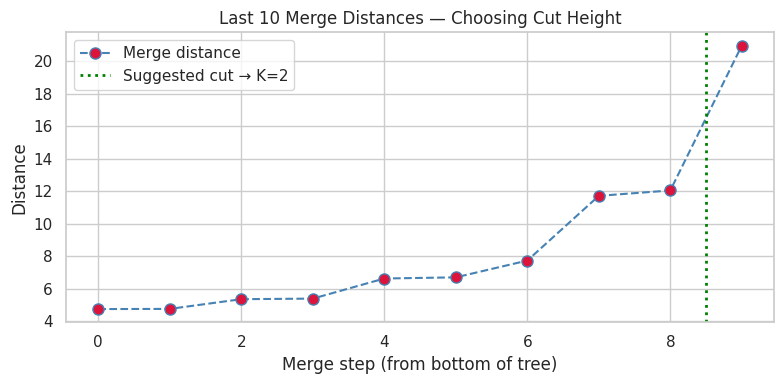

In [29]:
# Visualise the acceleration of merges to confirm
fig, ax = plt.subplots(figsize=(8, 4))
x_ticks = range(len(last_merges))
ax.plot(x_ticks, last_merges, marker='o', color='steelblue', linestyle='--',
        markerfacecolor='crimson', markersize=8, label='Merge distance')
ax.axvline(x=best_cut_idx + 0.5, color='green', linestyle=':', linewidth=2,
           label=f'Suggested cut → K={suggested_k}')
ax.set_title('Last 10 Merge Distances — Choosing Cut Height', fontsize=12)
ax.set_xlabel('Merge step (from bottom of tree)')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Summary — K-Means vs Hierarchical Clustering

### K-Means

**Advantages:**
1. **Fast and scalable:** Runs in $O(N \cdot K \cdot I)$ time where $I$ is the number of iterations. Handles millions of rows with ease.
2. **Simple to implement and tune:** Only one main hyperparameter ($K$).
3. **Works well when clusters are convex and similarly sized.**

**Disadvantages:**
1. **Must specify $K$ in advance:** You need to guess how many groups exist before you start.
2. **Sensitive to initialisation:** Different random starts can produce different results (mitigated by `n_init`).
3. **Assumes spherical clusters:** Performs poorly on elongated, ring-shaped, or very unevenly sized clusters.
4. **Sensitive to outliers:** A single extreme point can pull a centroid off-centre.

---

### Hierarchical (Agglomerative) Clustering

**Advantages:**
1. **No need to pre-specify $K$:** You fit once and cut the dendrogram at any level.
2. **Produces the full dendrogram:** The tree itself is an insight — it shows the hierarchical structure of your data.
3. **Deterministic:** No random initialisation; the same data always produces the same result.
4. **Flexible linkage:** Can discover non-spherical cluster shapes depending on the linkage chosen.

**Disadvantages:**
1. **Computationally expensive:** $O(N^2 \log N)$ or worse — does not scale to large datasets (>10,000 rows).
2. **Merges are irreversible:** Once two points are merged, they can never be separated.
3. **Sensitive to linkage choice:** Results can differ dramatically depending on `ward`, `complete`, `average`, or `single`.
